In [3]:
import pandas as pd

In [4]:
matches_df = pd.read_csv('../data/matches_cleaned.csv')

In [5]:
columns_to_drop = ['date','season','match_type','result','result_margin','player_of_match','umpire1','umpire2']

matches_df = matches_df.drop(columns = columns_to_drop,axis = 1)

matches_df.shape

(1090, 12)

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()
text_columns = ['city','venue','team1','team2','toss_winner','toss_decision','winner']

In [8]:
for col in text_columns:
    matches_df[col] = encoder.fit_transform(matches_df[col])

matches_df.head()

,id,city,venue,team1,team2,toss_winner,toss_decision,winner,target_runs,target_overs,super_over,method
0,335982,2,23,13,6,16,1,6,223.0,20.0,N,NaN
1,335983,7,40,10,0,0,0,0,241.0,20.0,N,NaN
2,335984,10,16,2,11,13,0,2,130.0,20.0,N,NaN
3,335985,26,55,8,13,10,0,13,166.0,20.0,N,NaN
4,335986,23,14,6,1,1,0,6,111.0,20.0,N,NaN


In [12]:
matches_df['super_over'] = matches_df['super_over'].replace({'N':0,'Y':1})

#matches_df = matches_df.drop(columns=['method'],axis = 1)

matches_df.dtypes

id                 int64
city               int64
venue              int64
team1              int64
team2              int64
toss_winner        int64
toss_decision      int64
winner             int64
target_runs      float64
target_overs     float64
super_over         int64
method            object
dtype: object

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
X = matches_df.drop('winner',axis=1)
y = matches_df['winner']

print("Dimensions of X:",X.shape)
print("Dimensions of y:",y.shape)

Dimensions of X: (1090, 11)
Dimensions of y: (1090,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data size:", X_train.shape)
print("Test Data size:", X_test.shape)

Training Data size: (872, 11)
Test Data size: (218, 11)


In [17]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("Missing values in y_train:")
print(y_train.isnull().sum())

Missing values in X_train:
id                 0
city               0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
target_runs        0
target_overs       0
super_over         0
method           858
dtype: int64
Missing values in y_train:
0


In [18]:
X_train = X_train.drop(columns=['method','id'],axis=1)
X_test = X_test.drop(columns=['method','id'],axis=1)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state = 42)
model.fit(X_train,y_train)
print("The Model Training is Complete")

The Model Training is Complete


In [19]:
from sklearn.metrics import accuracy_score
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)
print("Model Accuracy:",round(accuracy * 100,2),"%")

Model Accuracy: 51.83 %


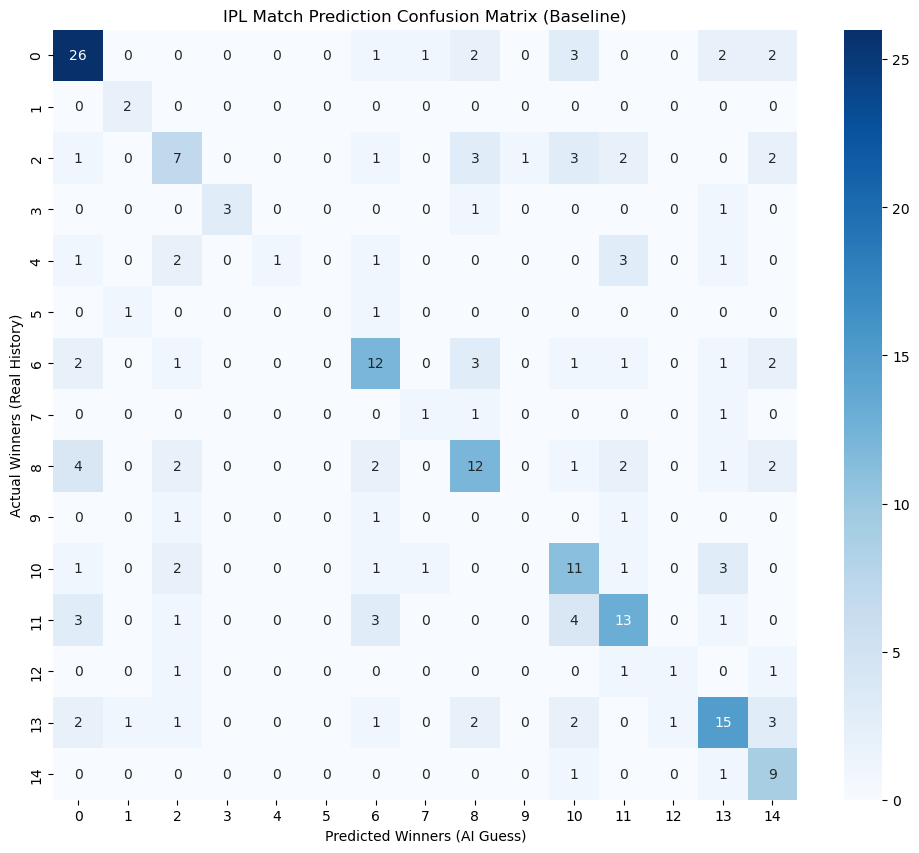

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,predictions)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('IPL Match Prediction Confusion Matrix (Baseline)')
plt.xlabel('Predicted Winners (AI Guess)')
plt.ylabel('Actual Winners (Real History)')

plt.show()

In [22]:
team_dictionary = dict(enumerate(encoder.classes_))

for number, team in team_dictionary.items():
    print(f"{number}:{team}")

0:Chennai Super Kings
1:Deccan Chargers
2:Delhi Capitals
3:Gujarat Lions
4:Gujarat Titans
5:Kochi Tuskers Kerala
6:Kolkata Knight Riders
7:Lucknow Super Giants
8:Mumbai Indians
9:Pune Warriors
10:Punjab Kings
11:Rajasthan Royals
12:Rising Pune Supergiants
13:Royal Challengers Bengaluru
14:Sunrisers Hyderabad


In [26]:
import joblib

joblib.dump(model, 'ipl_prediction_model.pkl')
joblib.dump(encoder, 'team_encoder.pkl')

print("Files saved ! Jupyter Notebook phase is completed")

Files saved ! Jupyter Notebook phase is completed


In [27]:
import os
print("Your Files are saved exactly here:")
print(os.getcwd())

Your Files are saved exactly here:
C:\Users\yuvas\Documents\IPL Project\notebooks
